In [59]:
########## import library ##########
import os
import re
import csv
import cv2
import glob
import time
import pickle

import numpy as np
from insightface.app import FaceAnalysis

In [62]:
fa = FaceAnalysis(name="buffalo_sc", root=f"", providers=["CPUExecutionProvider"])
fa.prepare(ctx_id=-1, det_thresh=0.5, det_size=(640, 640))

Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: models\buffalo_sc\det_500m.onnx detection [1, 3, '?', '?'] 127.5 128.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: models\buffalo_sc\w600k_mbf.onnx recognition ['None', 3, 112, 112] 127.5 127.5
set det-size: (640, 640)


In [63]:
path_images = glob.glob(os.path.join("data/**/", "*.jpg"))
path_images = [path_image.split("\\") for path_image in path_images]

path_images

[['data', 'AN VANNEATH', 'data (1).jpg'],
 ['data', 'AN VANNEATH', 'data_2025_04_03_13_10_24.jpg'],
 ['data', 'CHEAL RACHHANN', 'data (1).jpg'],
 ['data', 'CHHAM CHHANVICHEKA', 'data_2025_04_04_10_58_17.jpg'],
 ['data', 'CHHIT CHANTOLA', 'data (2).jpg'],
 ['data', 'CHHORN SOPHORT', 'data (1).jpg'],
 ['data', 'CHHUN CHANTHA', 'data (1).jpg'],
 ['data', 'CHHUN CHANTHA', 'data (2).jpg'],
 ['data', 'DARA SOPHORN', 'data (1).jpg'],
 ['data', 'DARA SOPHORN', 'data (2).jpg'],
 ['data', 'DARA SOPHORN', 'data_2025_04_03_13_08_48.jpg'],
 ['data', 'DETH RATHANAK', 'data (1).jpg'],
 ['data', 'DETH RATHANAK', 'data (2).jpg'],
 ['data', 'DIEB CHISAING', 'data (1).jpg'],
 ['data', 'DIEB CHISAING', 'data (2).jpg'],
 ['data', 'EANG SAOSAKAL', 'data (1).jpg'],
 ['data', 'ENG SOPHEAK', 'data_2025_04_04_10_58_34.jpg'],
 ['data', 'HENG TYKEA', 'data (1).jpg'],
 ['data', 'HENG TYKEA', 'data (2).jpg'],
 ['data', 'HUN MEILY', 'data (1).jpg'],
 ['data', 'KAO KIMHAK', 'data (1).jpg'],
 ['data', 'KAO KIMHAK', 'd

In [52]:
import matplotlib.pyplot as plt

In [53]:
"/".join(path_images[0])

'data/AN VANNEATH/data (1).jpg'

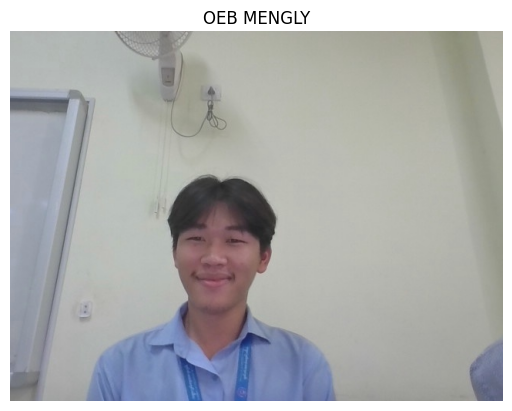

In [55]:
i = 50

img1 = cv2.imread("/".join(path_images[i]))
img1 = cv2.cvtColor(img1, cv2.COLOR_BGR2RGB)

plt.title(path_images[i][1])
plt.imshow(img1)
plt.axis("off")
plt.show()

In [ ]:
database = []



In [56]:
img1.shape

(480, 640, 3)

In [64]:
faces = fa.get(cv2.imread("/".join(path_images[i])))

In [70]:
faces.__len__()

1

In [72]:
faces[0].embedding.shape

(512,)

In [ ]:
def get_face_embedding(input):

    faces = fa.get(cv2.imread(input), max_num=MAX_NUMBER_FACE)

    if len(faces) == 0:
        print(f"Warning: no face detected in {input}")
        os.remove(input)
        return None

    elif len(faces) == 1:
        main_face = faces[0]

    elif len(faces) > 1:
        print(f"Warning: {len(faces)} faces detected in {input}")
        main_face = max(faces, key=lambda x: x.bbox[2] - x.bbox[0])

    box = main_face.bbox
    if box[2] - box[0] < MIN_FACE_SIZE or box[3] - box[1] < MIN_FACE_SIZE:
        print(f"Warning: face size is too small in {input}")
        os.remove(input)
        return None
    else:
        return main_face.embedding



In [ ]:
########## initial variable ##########
VERSION = "1.26"
MIN_FACE_SIZE = 100  # minimum face size
MAX_NUMBER_FACE = 5

group_name = []  # group name
all_dirs_embs = []  # list of all embeddings
group_student_embs = []  # list of student embeddings
group_student_files = []  # list of student files
group_student_file_sizes = []  # list of student file sizes


if not os.path.exists(f"{path_depth}resource/variable/similarity_threshold.pkl"):
    similarity_threshold = 0.6
    pickle.dump(similarity_threshold, open(f"{path_depth}resource/variable/similarity_threshold.pkl", "wb"))
else:
    similarity_threshold = pickle.load(open(f"{path_depth}resource/variable/similarity_threshold.pkl", "rb"))
########## __________ ##########

In [ ]:
# utility functions


database = f"{path_depth}database/"  # database path


def get_face_embedding(input):

    faces = fa.get(cv2.imread(input), max_num=MAX_NUMBER_FACE)

    if len(faces) == 0:
        print(f"Warning: no face detected in {input}")
        os.remove(input)
        return None

    elif len(faces) == 1:
        main_face = faces[0]

    elif len(faces) > 1:
        print(f"Warning: {len(faces)} faces detected in {input}")
        main_face = max(faces, key=lambda x: x.bbox[2] - x.bbox[0])

    box = main_face.bbox
    if box[2] - box[0] < MIN_FACE_SIZE or box[3] - box[1] < MIN_FACE_SIZE:
        print(f"Warning: face size is too small in {input}")
        os.remove(input)
        return None
    else:
        return main_face.embedding


def compare_faces_cosine(emb1, emb2):
    similarity = np.dot(emb1, emb2) / (np.linalg.norm(emb1) * np.linalg.norm(emb2))
    return similarity


def get_list_folders(input, pattern=None):

    if pattern is not None:
        return [f for f in os.listdir(input) if os.path.isdir(os.path.join(input, f)) and re.search(pattern, f)]
    else:
        return [f for f in os.listdir(input) if os.path.isdir(os.path.join(input, f))]


def get_list_files(input, pattern=None):

    if pattern is None:
        return [f for f in os.listdir(input) if os.path.isfile(os.path.join(input, f))]
    else:
        return [f for f in os.listdir(input) if os.path.isfile(os.path.join(input, f)) and re.search(pattern, f)]


def scan_directory(input):

    data = {}
    for group in get_list_folders(input):
        data[group] = {}
        for student in get_list_folders(f"{input}/{group}"):
            data[group][student] = get_list_files(f"{input}/{group}/{student}", "jpg")
    return data


def get_name_embs(input):

    all_dirs_embs = []
    for n in input:
        tmp = []
        for e in input[n]:
            tmp.append(e)
        all_dirs_embs.append([n, tmp])

    return all_dirs_embs


def get_group_student_embs(input):
    output = {}
    for g in input:
        output[g] = {}
        for s in input[g]:
            output[g][s] = []
            for f in input[g][s]:
                # IMPORTANT: check if the file is in prev_group_student_files
                if group_student_files == [] or (group_student_files.get(g) is None) or (group_student_files[g].get(s) is None) or (f not in group_student_files[g][s]):
                    output[g][s] = [get_face_embedding(f"{database}/{g}/{s}/{f}")]
                else:
                    output[g][s] = group_student_embs[g][s]
    return output


def get_group_student_file_size(input):

    output = {}
    for g in input:
        output[g] = {}
        for s in input[g]:
            output[g][s] = {}
            for f in input[g][s]:
                output[g][s][f] = os.path.getsize(f"{database}/{g}/{s}/{f}")
    return output


def get_list_camera_devices():

    index = 0
    cameras = []

    while True:
        cap = cv2.VideoCapture(index)
        if not cap.isOpened():
            break
        cap.release()
        cameras.append(f"Camera #{index}")
        index += 1
    return cameras


cameras = get_list_camera_devices()

cap = cv2.VideoCapture(0)

In [ ]:
def load_database():
    global group_student_files, group_student_embs

    if os.path.exists(f"{path_depth}resource/variable/group_student_files.pkl") and os.path.exists(f"{path_depth}resource/variable/group_student_embs.pkl"):
        group_student_files = pickle.load(open(f"{path_depth}resource/variable/group_student_files.pkl", "rb"))
        group_student_embs = pickle.load(open(f"{path_depth}resource/variable/group_student_embs.pkl", "rb"))

    _group_student_files = scan_directory(database)

    if _group_student_files != group_student_files:
        print("Database Updating...")
        _group_student_embs = get_group_student_embs(_group_student_files)
        for g in _group_student_embs:
            for s in _group_student_embs[g]:
                for e in _group_student_embs[g][s]:
                    if e is None:
                        print(f"Warning: database/{g}/{s}/{e} has no face detected")
                        _group_student_embs[g][s] = []
                        _group_student_files[g][s] = []

        group_student_files = _group_student_files
        group_student_embs = _group_student_embs
        pickle.dump(group_student_files, open(f"{path_depth}resource/variable/group_student_files.pkl", "wb"))
        pickle.dump(group_student_embs, open(f"{path_depth}resource/variable/group_student_embs.pkl", "wb"))

    else:
        print("Database Loading...")
        group_student_embs = pickle.load(open(f"{path_depth}resource/variable/group_student_embs.pkl", "rb"))

    print("Database Load Successfully")


load_database()



# if group_student_files has data
if group_student_files:
    group_name = list(group_student_files.keys())[0]
    all_dirs_embs = get_name_embs(group_student_embs[group_name])

Database Loading...
Database Load Successfully
